# AI vs. Human Content Detection: A Multilingual Analysis
**Shradha Bhatia**  
**April 17, 2026**

## Introduction

The rise of large language models (LLMs) like Llama, Gemma, and GPT-based systems has made it increasingly difficult to distinguish AI-generated text from human-written content. This has real consequences in education, journalism, and professional settings, where the authenticity of written work matters. Existing detection tools often rely on English-only or single-model datasets, which limits their real-world effectiveness.

This report analyzes the **AI vs. Human Content Detection Dataset (2026 Edition)**, created by Muhammad Afaq Bhatti and made publicly available on Kaggle. The dataset was generated on January 29, 2026, by collecting human-written samples and pairing them with AI-generated content produced using Llama 3.1 8B Instant, Llama 3.3 70B, and Gemma 2 9B. A subset of AI samples were then lightly or heavily post-edited by humans, creating three distinct content categories.

The dataset contains **686 observations** and **11 variables**:

- `id`: Unique UUID string for each sample
- `text`: Full text of the sample
- `human_or_ai`: Label — human, ai, or post_edited_ai
- `source_model`: The AI model used, or "Human" for human-written samples
- `prompt`: The prompt used to generate AI content (null for human samples)
- `domain`: One of: Education, Email, Marketing, News, Social Media, Technical Blog
- `language`: ISO 639-1 code (en, hi, ur, ar, es, fr, or code-mixed)
- `edit_level`: Degree of human editing — none, light, or heavy
- `word_count`: Word count (range: 9–1,121; mean: ~262)
- `generation_date`: Timestamp for when the sample was generated
- `version`: Dataset version label

**Class breakdown:** 335 AI-generated (49%), 181 human-written (26%), 170 post-edited AI (25%)

**Missing data:** The `prompt` column has 181 null values, corresponding to human-written samples — expected, since those weren't generated from a prompt.

One important limitation: post-edited samples vary in revision depth, making the boundary between AI and human authorship fuzzy for that category. LLM writing styles also evolve rapidly, so detection patterns observed here may shift over time.

## Data Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
PALETTE = {'ai': '#4E79A7', 'human': '#59A14F', 'post_edited_ai': '#F28E2B'}

In [3]:
data = pd.read_csv('ai_human_detection_v1.csv')
print(data.head())

                                     id  \
0  e37e31c0-35d0-486d-9760-efadd4e0e289   
1  68e294cf-a499-4fbf-8616-2d6324570be9   
2  b5e06ef0-9758-471f-81dc-182c6117ee81   
3  6177fc40-1567-445b-af15-f3250ddd3403   
4  192a9615-ed51-4750-b649-d18f8882f555   

                                                text human_or_ai  \
0  Aprender programación en Python es fácil . Pri...       human   
1  Error: 400 Client Error: Bad Request for url: ...          ai   
2  Error: 404 Client Error: Not Found for url: ht...          ai   
3  **Global Economic Trends: A Shifting Landscape...          ai   
4  "Recuerda que tú eres fuerte, capaz y única. N...          ai   

                          source_model  \
0                                Human   
1                         gemma2-9b-it   
2  gemma2-9b-itllama-3.3-70b-versatile   
3                 llama-3.1-8b-instant   
4                 llama-3.1-8b-instant   

                                              prompt          domain language  

In [4]:
print(data.info())
print(f'Shape: {data.shape}')
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               686 non-null    object
 1   text             686 non-null    object
 2   human_or_ai      686 non-null    object
 3   source_model     686 non-null    object
 4   prompt           505 non-null    object
 5   domain           686 non-null    object
 6   language         686 non-null    object
 7   edit_level       686 non-null    object
 8   word_count       686 non-null    int64 
 9   generation_date  686 non-null    object
 10  version          686 non-null    object
dtypes: int64(1), object(10)
memory usage: 59.1+ KB
None
Shape: (686, 11)
        word_count
count   686.000000
mean    262.300292
std     203.517607
min       9.000000
25%      57.000000
50%     245.000000
75%     393.500000
max    1121.000000


In [5]:
print(data['human_or_ai'].value_counts())
print(data['domain'].value_counts())
print(data['language'].value_counts())
print(data.isnull().sum())

human_or_ai
ai                335
human             181
post_edited_ai    170
Name: count, dtype: int64
domain
Social Media      121
Marketing         121
Technical Blog    118
Email             117
News              106
Education         103
Name: count, dtype: int64
language
en            246
hi             99
ur             93
ar             79
es             70
fr             52
code-mixed     47
Name: count, dtype: int64
id                   0
text                 0
human_or_ai          0
source_model         0
prompt             181
domain               0
language             0
edit_level           0
word_count           0
generation_date      0
version              0
dtype: int64


The dataset is clean and well-structured. Word counts vary significantly across samples, and domains and languages are relatively balanced. The only missing values are in `prompt`, which is expected, human-written samples don't have prompts.

## Research Question 1: How do word counts differ between content types, and does domain amplify those differences?

Word count is one of the most accessible signals for content detection. AI models tend to generate verbose responses to fill prompts, while human-written text — especially informal content like social media posts — tends to be shorter. This question asks not just whether differences exist, but whether domain moderates them: does AI write especially long Technical Blogs? Are human social media posts especially short?

In [6]:
word_stats = data.groupby('human_or_ai')['word_count'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
print(word_stats)

                      mean  median         std  min   max  count
human_or_ai                                                     
ai              373.916418   347.0  177.848988    9  1121    335
human            39.082873    33.0   18.872931   12   104    181
post_edited_ai  280.011765   256.0  163.148714    9   873    170


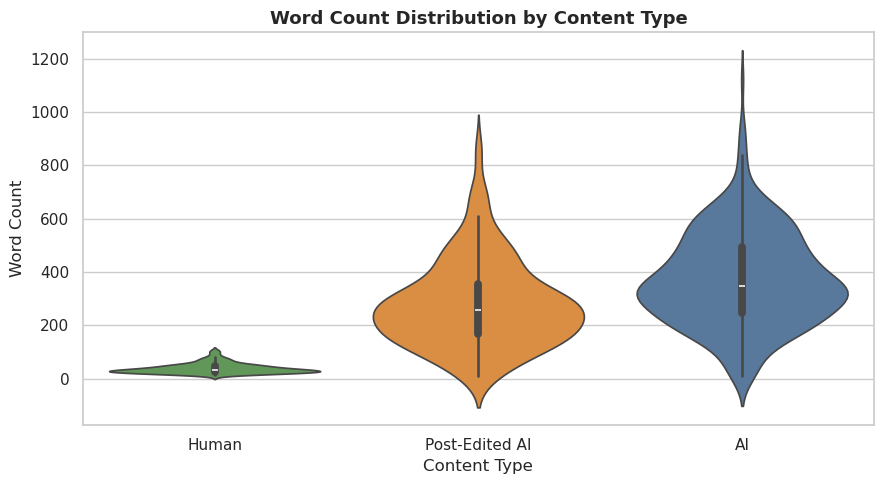

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ['human', 'post_edited_ai', 'ai']
sns.violinplot(data=data, x='human_or_ai', y='word_count',
               order=order, hue='human_or_ai', palette=PALETTE,
               inner='box', legend=False, ax=ax)
ax.set_title('Word Count Distribution by Content Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Word Count')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Human', 'Post-Edited AI', 'AI'])
plt.tight_layout()
plt.show()

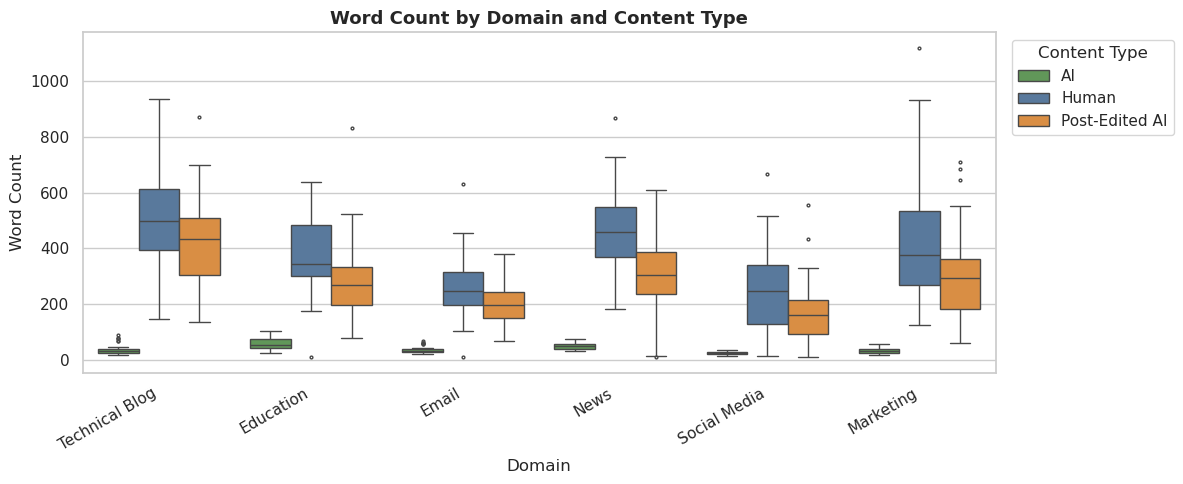

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=data, x='domain', y='word_count', hue='human_or_ai',
            palette=PALETTE, fliersize=2, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['AI', 'Human', 'Post-Edited AI'], title='Content Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('Word Count by Domain and Content Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Domain')
ax.set_ylabel('Word Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Human-written content is strikingly short — with a median of just 33 words — compared to AI-generated (median ~347 words) and post-edited AI (median ~256 words). This gap is consistent across domains, but Technical Blog and News show the widest divergence between human and AI samples. The violin plots also reveal that AI content has a broader distribution, occasionally exceeding 1,000 words.

Post-edited AI sits in between, suggesting that human editing reduces but does not fully eliminate AI verbosity. Word count is likely one of the strongest single-feature signals for detection in this dataset.

## Research Question 2: Which content types dominate each domain, and does that pattern hold across all three labels?

Earlier analysis looked at AI percentage alone. Here we go deeper: how are all three content types distributed across domains? A domain with "low AI %" might actually have high post-edited AI content — which matters just as much for detection research.

In [10]:
domain_ai = data.groupby('domain').agg({
    'domain': 'count',
    'human_or_ai': lambda x: (x == 'ai').sum()
}).rename(columns={'domain': 'total', 'human_or_ai': 'ai_count'})
print(domain_ai)

domain_ai_pct = data.groupby('domain').agg(
    ai_percent=('human_or_ai', lambda x: 100 * (x == 'ai').sum() / len(x)),
    post_edited_percent=('human_or_ai', lambda x: 100 * (x == 'post_edited_ai').sum() / len(x)),
    human_percent=('human_or_ai', lambda x: 100 * (x == 'human').sum() / len(x))
).sort_values('ai_percent', ascending=False)
print(domain_ai_pct)

                total  ai_count
domain                         
Education         103        46
Email             117        59
Marketing         121        58
News              106        52
Social Media      121        60
Technical Blog    118        60
                ai_percent  post_edited_percent  human_percent
domain                                                        
Technical Blog   50.847458            20.338983      28.813559
Email            50.427350            23.931624      25.641026
Social Media     49.586777            23.966942      26.446281
News             49.056604            25.471698      25.471698
Marketing        47.933884            28.099174      23.966942
Education        44.660194            27.184466      28.155340


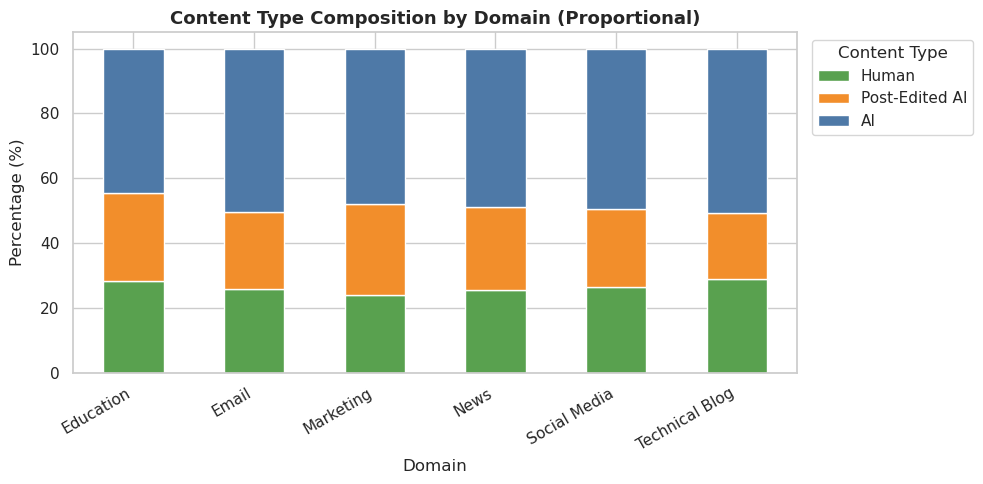

In [11]:
domain_summary = data.groupby(['domain', 'human_or_ai']).size().unstack(fill_value=0)
domain_summary_pct = domain_summary.div(domain_summary.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
domain_summary_pct[['human', 'post_edited_ai', 'ai']].plot(
    kind='bar', stacked=True,
    color=['#59A14F', '#F28E2B', '#4E79A7'],
    ax=ax
)
ax.set_title('Content Type Composition by Domain (Proportional)', fontsize=13, fontweight='bold')
ax.set_xlabel('Domain')
ax.set_ylabel('Percentage (%)')
ax.legend(['Human', 'Post-Edited AI', 'AI'], title='Content Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

AI-generated content makes up roughly 45-51% across all six domains, a remarkably uniform
spread. Marketing has a higher share of post-edited AI (28%), while Technical Blog has a
higher proportion of human text (29%). But overall, no domain is dominated by or immune
to AI content.

Detection systems cannot rely on domain as a filtering heuristic. Every domain has roughly
half AI-generated text, and ignoring post-edited AI misses a significant proportion of
non-human content.

## Research Question 3: How does language interact with content type and word length?

Language is an underexplored dimension in most AI detection research. Models trained primarily on English may behave differently across other languages. We already know Hindi (hi) and English (en) have the highest AI percentages (~60% and ~57%). But why? One hypothesis: AI models generate longer outputs in some languages, which could inflate their AI percentages. Another: human-written content was harder to source at scale for certain languages.

In [13]:
lang_count = data.groupby('language').agg({
    'language': 'count',
    'human_or_ai': lambda x: (x == 'ai').sum()
}).rename(columns={'language': 'total', 'human_or_ai': 'ai_count'}).sort_values('total', ascending=False)
print(lang_count)

lang_ai_pct = data.groupby('language').agg(
    ai_percent=('human_or_ai', lambda x: 100 * (x == 'ai').sum() / len(x))
).sort_values('ai_percent', ascending=False)
print(lang_ai_pct)

            total  ai_count
language                   
en            246       141
hi             99        60
ur             93        50
ar             79        35
es             70        21
fr             52        15
code-mixed     47        13
            ai_percent
language              
hi           60.606061
en           57.317073
ur           53.763441
ar           44.303797
es           30.000000
fr           28.846154
code-mixed   27.659574


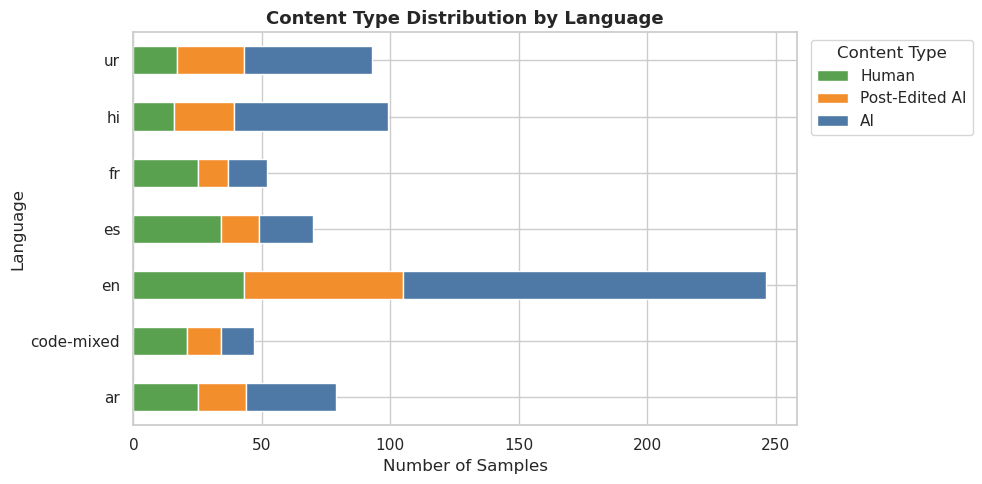

In [14]:
language_summary = data.groupby(['language', 'human_or_ai']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
language_summary[['human', 'post_edited_ai', 'ai']].plot(
    kind='barh', stacked=True,
    color=['#59A14F', '#F28E2B', '#4E79A7'],
    ax=ax
)
ax.set_title('Content Type Distribution by Language', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Language')
ax.legend(['Human', 'Post-Edited AI', 'AI'], title='Content Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

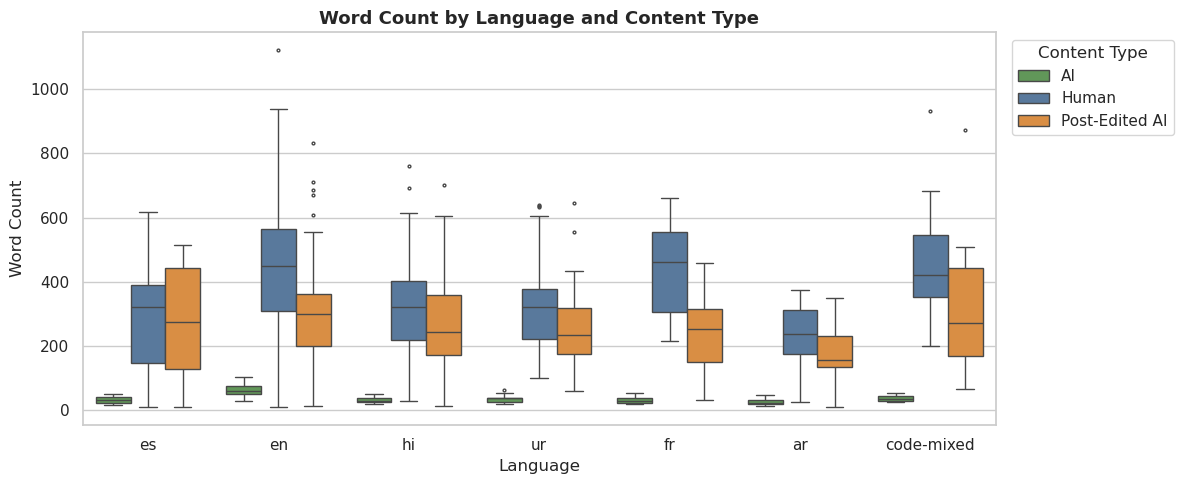

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=data, x='language', y='word_count', hue='human_or_ai',
            palette=PALETTE, fliersize=2, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['AI', 'Human', 'Post-Edited AI'], title='Content Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('Word Count by Language and Content Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Language')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.show()

The gap between AI and human word counts is present across all languages, but varies in magnitude. English shows the widest gap, while code-mixed content is more compressed overall. Hindi and Urdu have the highest AI percentages (60.6% and 53.8%), which may reflect dataset collection choices rather than intrinsic linguistic differences.

Detection systems need language-specific calibration. A model tuned on English data alone will likely underperform on Hindi, Urdu, or multilingual content.

## Conclusion

This analysis reveals several consistent patterns in the AI vs. Human Content Detection Dataset (2026 Edition):

**Word count is a powerful signal.** Human-written samples are dramatically shorter (median 33 words) than AI-generated (median ~347) or post-edited AI (median ~256). This gap is consistent across all domains and is likely the strongest single-feature detection signal in this dataset.

**Post-edited AI occupies a middle ground.** Its word counts and content distributions suggest human editing partially closes the gap between AI and human writing, but does not eliminate it. This is an important nuance for building realistic detection benchmarks.

**Domain does not strongly separate content types.** AI content makes up roughly 45–51% of every domain. No domain is safe from AI-generated text, and domain-based filtering would not be a reliable detection strategy.

**Language matters for AI rates, but the reasons are unclear.** Hindi and English have the highest AI percentages, while Spanish, French, and code-mixed text have the lowest. The word count gap also varies by language. Multilingual detection systems need to account for these differences rather than assuming uniform behavior across languages.

Overall, this dataset highlights the complexity of AI content detection in real-world conditions — across domains, languages, and editing levels — and underscores the need for diverse, multilingual training data for detection tools.